In [1]:
# Degraded audio robustness evaluation (FR-006 second half): compression, noise and pitch shift
# This notebook is separate from robustness_eval.ipynb to keep its own clean top to bottom flow.

from google.colab import drive
drive.mount("/content/drive") # mount Drive so we can reach the model and the audio

import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torchvision import models

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load the trained CNN (same setup as the training and robustness notebooks)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # use the GPU if available

# rebuild the exact ResNet18 shape used in training
model = models.resnet18(weights=None) # empty skeleton

model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False) # 1 channel in (greyscale spectrogram)

model.fc = nn.Linear(model.fc.in_features, 1) # 1 output (real vs fake)

# load the trained weights from Drive
model_path = "/content/drive/MyDrive/ai-music-detector/cnn_resnet18_best.pth"

model.load_state_dict(torch.load(model_path, map_location=device))

model.to(device) # move the model onto the GPU

model.eval() # evaluation mode

print("Model loaded on", device)

Model loaded on cuda


In [3]:
# Find the raw SONICS audio in Drive (need audio files to degrade. not spectrograms)
import os

base = "/content/drive/MyDrive/ai-music-detector"

# check the likely audio locations and count whats inside
for path in [f"{base}/data/audio",
             f"{base}/data/audio/real",
             f"{base}/data/audio/fake",
             f"{base}/data"]:

    if os.path.exists(path):

        items = os.listdir(path)

        print(f"EXISTS: {path}  ({len(items)} items)")

        print("   sample:", items[:3]) # show a few names so we can see whats there

    else:

        print(f"missing: {path}")

missing: /content/drive/MyDrive/ai-music-detector/data/audio
missing: /content/drive/MyDrive/ai-music-detector/data/audio/real
missing: /content/drive/MyDrive/ai-music-detector/data/audio/fake
EXISTS: /content/drive/MyDrive/ai-music-detector/data  (5 items)
   sample: ['valid.csv', 'test.csv', '.cache']


In [4]:
# Pick a balanced sample of test tracks to degrade, then list exactly which audio files to upload
# read the split table straight from the public repo (avoids any Drive path guessing)
splits_url = "https://raw.githubusercontent.com/cianbond/ai-music-detector/main/data/subset_splits.csv"

splits = pd.read_csv(splits_url)

test = splits[splits["split"] == "test"].copy() # only the held out test tracks

# split the test set into the three groups we want represented
reals = test[test["filename"].str.startswith("real_")]

suno  = test[test["filename"].str.contains("suno")]

udio  = test[test["filename"].str.contains("udio")]

# take a fixed sample of each (seed 42 so it is reproducible)
sample = pd.concat([
    reals.sample(15, random_state=42),
    suno.sample(15, random_state=42),
    udio.sample(10, random_state=42),
])

print("Sampled", len(sample), "tracks. Upload these audio files:\n")

for name in sample["filename"]:

    ext = ".mp3" if name.startswith("fake_") else ".wav" # fakes are mp3, reals are wav

    print(f"  {name}{ext}")

# save the sample list so later cells know which tracks to use
sample.to_csv("/content/sample_list.csv", index=False)

print("\nSaved the sample list to /content/sample_list.csv")

Sampled 40 tracks. Upload these audio files:

  real_06676.wav
  real_52806.wav
  real_29083.wav
  real_11355.wav
  real_03247.wav
  real_07387.wav
  real_32192.wav
  real_46862.wav
  real_40642.wav
  real_26136.wav
  real_04467.wav
  real_25372.wav
  real_51990.wav
  real_38358.wav
  real_20731.wav
  fake_52426_suno_1.mp3
  fake_15899_suno_1.mp3
  fake_16882_suno_0.mp3
  fake_39300_suno_1.mp3
  fake_13877_suno_1.mp3
  fake_40144_suno_1.mp3
  fake_09632_suno_0.mp3
  fake_01674_suno_0.mp3
  fake_53685_suno_1.mp3
  fake_14807_suno_0.mp3
  fake_18936_suno_1.mp3
  fake_30364_suno_0.mp3
  fake_17080_suno_0.mp3
  fake_09831_suno_1.mp3
  fake_08948_suno_1.mp3
  fake_48328_udio_1.mp3
  fake_43437_udio_1.mp3
  fake_17415_udio_0.mp3
  fake_50088_udio_1.mp3
  fake_28496_udio_0.mp3
  fake_53992_udio_1.mp3
  fake_03374_udio_1.mp3
  fake_50096_udio_1.mp3
  fake_50163_udio_0.mp3
  fake_02669_udio_0.mp3

Saved the sample list to /content/sample_list.csv


In [5]:
# Confirm the uploaded sample landed on Drive (a missing file would skew the results)
sample_dir = "/content/drive/MyDrive/ai-music-detector/sample_audio"

files = os.listdir(sample_dir)

audio = [f for f in files if f.endswith((".wav", ".mp3"))] # just the audio. not the csv

print("Total items in folder:", len(files))

print("Audio files:", len(audio))

print("Real:", len([f for f in audio if f.startswith("real_")]))

print("Suno:", len([f for f in audio if "suno" in f]))

print("Udio:", len([f for f in audio if "udio" in f]))

print("sample_list.csv present:", "sample_list.csv" in files)

Total items in folder: 41
Audio files: 40
Real: 15
Suno: 15
Udio: 10
sample_list.csv present: True


In [6]:
# Clean baseline: run the 40 undegraded tracks through the model to get a reference F1
from sklearn.metrics import f1_score, accuracy_score

# load the label list we saved alongside the audio (filename + true target)
labels = pd.read_csv(f"{sample_dir}/sample_list.csv")

# turn one waveform into a spectrogram the model can read and then predict (1 = fake, 0 = real)
def predict_waveform(y, sr=16000):

    # take a centred 15 second clip (same as preprocess.py), skip if too short
    clip_len = 15 * sr

    if len(y) < clip_len:

        return None

    middle = len(y) // 2

    half = clip_len // 2

    clip = y[middle - half : middle + half] # the centred 15s clip

    # clip to mel-spectrogram in dB (identical to the training pipeline)
    mel = librosa.feature.melspectrogram(y=clip, sr=sr, n_mels=128)

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # shape it for the model and run it
    tensor = torch.tensor(mel_db).float().unsqueeze(0).unsqueeze(0).to(device) # (1, 1, 128, time)

    with torch.no_grad():

        logit = model(tensor)

        pred = 1 if torch.sigmoid(logit).item() >= 0.5 else 0 # verdict at the 0.5 cutoff

    return pred

# run every sample track through. clean (no degradation yet)
def evaluate(degrade=None, label=""):

    y_true, y_pred = [], []

    for _, row in labels.iterrows(): # each sampled track

        name = row["filename"]

        ext = ".mp3" if name.startswith("fake_") else ".wav"

        y, sr = librosa.load(f"{sample_dir}/{name}{ext}", sr=16000) # load the audio

        if degrade is not None: # apply a degradation if one was passed in

            y = degrade(y, sr)

        pred = predict_waveform(y, sr)

        if pred is None: # skip any track too short for a clip

            continue

        y_true.append(row["target"])

        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    print(f"{label:<14} n={len(y_true):<3} accuracy={acc:.3f}  F1={f1:.3f}")

    return {"condition": label, "n": len(y_true), "accuracy": acc, "f1": f1}

# run the clean baseline (no degrade function passed)

results = [] # we will collect each condition's scores here

results.append(evaluate(degrade=None, label="Clean"))

Clean          n=40  accuracy=1.000  F1=1.000


In [7]:
# Condition 1 noise: add random gaussian noise to the waveform before predicting
def add_noise(y, sr, noise_level=0.005):

    noise = np.random.normal(0, noise_level, len(y)) # random noise. same length as the audio

    return y + noise # mix the noise into the signal

np.random.seed(42) # fixed seed so the noise is reproducible

results.append(evaluate(degrade=add_noise, label="Noise"))

Noise          n=40  accuracy=0.400  F1=0.077


In [8]:
# Condition 2 pitch shift: shift the pitch up two semitones before predicting
def pitch_shift(y, sr, semitones=2):

    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=semitones) # shift pitch by n_steps semitones

results.append(evaluate(degrade=pitch_shift, label="Pitch shift"))

Pitch shift    n=40  accuracy=0.400  F1=0.077


In [9]:
# Condition 3 compression: resample down to 8kHz and back to mimic lossy compression detail loss
def compress(y, sr, low_sr=8000):

    down = librosa.resample(y=y, orig_sr=sr, target_sr=low_sr) # drop to a lower sample rate (loses high frequency detail)

    up = librosa.resample(y=down, orig_sr=low_sr, target_sr=sr) # bring it back up so the length and rate match again

    return up

results.append(evaluate(degrade=compress, label="Compression"))

Compression    n=40  accuracy=0.550  F1=0.690


  condition  n  accuracy       f1
      Clean 40      1.00 1.000000
      Noise 40      0.40 0.076923
Pitch shift 40      0.40 0.076923
Compression 40      0.55 0.689655


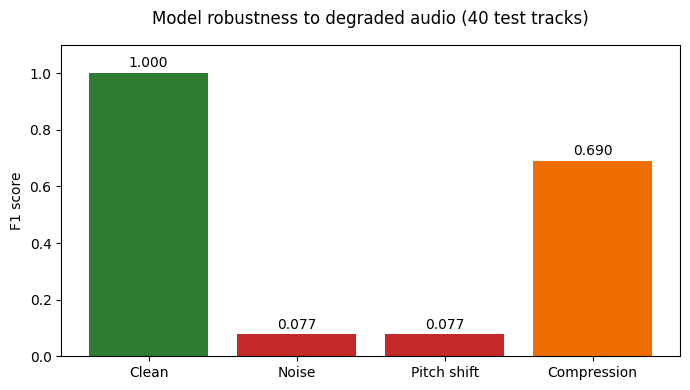

Saved figure to /content/drive/MyDrive/ai-music-detector/figures/degraded_audio_f1.png


In [12]:
# Build the results into a table and save it as a figure for the report
import matplotlib.pyplot as plt

df = pd.DataFrame(results) # results holds a dict per condition (condition, n, accuracy, f1)

df = df[["condition", "n", "accuracy", "f1"]] # order the columns

print(df.to_string(index=False)) # print the table to the notebook

# draw the F1 per condition as a simple bar chart
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(df["condition"], df["f1"], color=["#2e7d32", "#c62828", "#c62828", "#ef6c00"]) # green clean, red collapses, orange compression

ax.set_ylim(0, 1.1) # a little headroom so the 1.000 label isn't jammed at the top

ax.set_ylabel("F1 score")

ax.set_title("Model robustness to degraded audio (40 test tracks)", pad=15) # pad lifts the title clear of the bars

for i, v in enumerate(df["f1"]): # label each bar with its value

    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()

# save to Drive alongside the other report figures
fig_path = "/content/drive/MyDrive/ai-music-detector/figures/degraded_audio_f1.png"

fig.savefig(fig_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved figure to", fig_path)